# New adaptive point selection — robust fitting with sigma-clipping

## Problems with the original RSS-based sweep

**Problem 1 — bias toward minimum points:**  
Plain RSS grows as you add more points (more terms in the sum), so the optimizer always prefers using fewer points. We need a metric that *normalizes* by point count.

**Problem 2 — physically anomalous points:**  
Some points inside an injection span deviate from the exponential decay due to plasma instabilities. We know the true decay *must* be exponential (physics), so those points are measurement artifacts — not signal — and should be excluded.

## Proposed solutions

| Problem | Solution |
|---|---|
| RSS min-points bias | Use **reduced χ²** = RSS / (n − 2). Normalizes by degrees of freedom; adding a well-fitting point can only improve the score. |
| Anomalous / outlier points | **Iterative sigma-clipping**: fit on all injection points → compute residuals → remove points where \|r\| > k·MAD → refit → repeat until stable. Uses `scipy.optimize.least_squares` with `loss='soft_l1'` for the initial robust estimate. |

MAD (median absolute deviation) is the standard robust scatter estimator used in experimental physics and astronomy pipelines.


In [2]:
"""Cell 1 — Setup: imports, project root, load discharge, detect injections."""
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import least_squares, curve_fit

# --- locate project root so pha_lib is importable ---
def _find_root(start: Path) -> Path:
    for p in [start.resolve(), *start.resolve().parents]:
        if (p / "pha_lib").exists():
            return p
    raise FileNotFoundError("pha_lib not found")

ROOT = _find_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from pha_lib import io
from pha_lib.timetrace import integrate_energy_window
from pha_lib.discharges import detect_injections

# --- parameters ---
DISCHARGE_DIR = ROOT / "data" / "discharges" / "2025-04-29--10-19"
CHANNEL_ID    = 2
LINE_E        = 6660.0   # eV
HALF_W        = 60.0     # eV half-window

# --- load discharge and detect injections ---
discharge  = io.load_test_folder(DISCHARGE_DIR, discharge_id="2025-04-29--10-19")
channel    = discharge.channels[CHANNEL_ID]
trace      = integrate_energy_window(channel, LINE_E, HALF_W)
injections = detect_injections(trace, LINE_E)

print(f"Loaded: {discharge.discharge_id}")
print(f"Channel {CHANNEL_ID}: {len(injections)} injection(s) detected")
for inj in injections:
    print(f"  #{inj.injection_no}  frames {inj.start_frame}..{inj.finish_frame}  "
          f"(span={inj.finish_frame - inj.start_frame})")

# work on the first injection
injection = injections[0]
print(f"\nWorking on injection #{injection.injection_no}  "
      f"(start={injection.start_frame}, finish={injection.finish_frame})")


Loaded: 2025-04-29--10-19
Channel 2: 4 injection(s) detected
  #1  frames 98..106  (span=8)
  #2  frames 145..153  (span=8)
  #3  frames 192..200  (span=8)
  #4  frames 279..287  (span=8)

Working on injection #1  (start=98, finish=106)


In [4]:
"""Cell 2 — Core fitting helpers.

find_first_falling_frame():
  Returns the first frame of the LAST descent inside the injection span.
  For roller-coaster injections (events oscillate up-down before the final
  decay), this finds the last local maximum and returns the frame after it —
  i.e., the start of the final exponential decay.
  Falls back to start_frame+1 if no falling step is found.

fit_sigma_clip():
  1. Auto-detect t_0 using find_first_falling_frame().
  2. Fit the injection span (from t_0 to finish_frame) with soft_l1 robust
     loss to get an outlier-resistant seed.
  3. Compute residuals; mark outliers where |r| > sigma_thresh * MAD.
  4. Refit on inliers only (ordinary least-squares).
  5. Repeat until the inlier set stops changing or max_iter is reached.

Returns a dict with fit params, covariance, inlier mask, and quality metrics.
"""

_MAD_SCALE = 1.4826   # makes MAD equivalent to 1-sigma for Gaussian noise


def _exp_model(t, A, tau, t_0, C_bg):
    """Exponential decay: A * exp(-(t - t_0) / tau) + C_bg."""
    return A * np.exp(-(t - t_0) / tau) + C_bg


def _initial_guess(y_fit, t_0, C_bg):
    """Simple initial guess: A from first point above background, tau=1."""
    A0 = max(float(y_fit[0] - C_bg), 1.0)
    return [A0, 1.0]


def find_first_falling_frame(trace, injection) -> int:
    """Return the first frame of the LAST descent inside the injection span.

    For injections with roller-coaster oscillations (events go up-down
    several times before the final exponential decay), the current span may
    contain multiple local maxima.  This function finds the LAST local
    maximum and returns the frame immediately after it — the start of the
    final, physically meaningful decay.

    A local maximum at index i is defined as:
      v[i] >= v[i-1]  (or i is the first span point)
      v[i] >  v[i+1]

    Falls back to the first falling frame (original behaviour) if no local
    maximum is found in the interior, then to start_frame+1 if the span is
    monotonically non-decreasing.
    """
    fn = trace.frame_numbers
    v  = trace.values

    try:
        s_idx = int(np.where(fn == int(injection.start_frame))[0][0])
    except IndexError:
        return int(injection.start_frame + 1)

    try:
        e_idx = int(np.where(fn == int(injection.finish_frame))[0][0])
    except IndexError:
        e_idx = len(fn) - 1

    # --- find last local maximum in [s_idx, e_idx-1] ---
    # Scan forward; keep updating last_peak_idx every time a local max is found.
    # At the end, last_peak_idx holds the rightmost peak (last roller-coaster top).
    last_peak_idx = None
    for i in range(s_idx, e_idx):
        # local max condition: not lower than the previous point, and higher than next
        not_lower_than_prev = (i == s_idx) or (v[i] >= v[i - 1])
        higher_than_next    = v[i] > v[i + 1]
        if not_lower_than_prev and higher_than_next:
            last_peak_idx = i   # keep updating — we want the last one

    if last_peak_idx is not None:
        next_idx = last_peak_idx + 1
        if next_idx <= e_idx:
            # first falling frame of the final decay
            return int(fn[next_idx])

    # fallback 1: first falling step anywhere in the span (original behaviour)
    for i in range(s_idx + 1, e_idx + 1):
        if v[i] < v[i - 1]:
            return int(fn[i])

    # fallback 2: monotonically non-decreasing — use original convention
    return int(injection.start_frame + 1)


def fit_sigma_clip(
    trace,
    injection,
    sigma_thresh: float = 2.5,
    max_iter: int = 10,
    min_inliers: int = 4,
) -> dict:
    """Robust iterative sigma-clipping fit over the injection decay span.

    Parameters
    ----------
    trace          : TimeTrace with .frame_numbers and .values
    injection      : Injection with .start_frame and .finish_frame
    sigma_thresh   : outlier threshold in units of MAD
    max_iter       : maximum number of sigma-clip iterations
    min_inliers    : minimum inliers required to keep a fit valid

    Returns
    -------
    dict with keys:
      success, A, tau, t_0, C_bg, A_err, tau_err,
      inlier_mask (bool array over injection span),
      n_total, n_inliers, inlier_fraction,
      rss_inliers, rmse_inliers, reduced_chi2,
      tau_err_rel, message, iterations
    """
    fn = trace.frame_numbers
    v  = trace.values

    # t_0: first frame of the last descent (handles roller-coaster injections)
    t_0  = float(find_first_falling_frame(trace, injection))
    C_bg = float(np.median(v))

    # --- locate the decay span in the trace: from t_0 to finish_frame ---
    try:
        start_idx = int(np.where(fn == int(t_0))[0][0])
    except IndexError:
        return _fail(f"t_0={int(t_0)} not in trace", t_0, C_bg)

    try:
        end_idx = int(np.where(fn == int(injection.finish_frame))[0][0]) + 1
    except IndexError:
        end_idx = len(fn)
    end_idx = max(end_idx, start_idx + min_inliers)

    t_all   = fn[start_idx:end_idx].astype(float)
    y_all   = v[start_idx:end_idx].astype(float)
    n_total = len(t_all)

    if n_total < min_inliers:
        return _fail(f"decay span too short ({n_total} pts)", t_0, C_bg)

    # --- Step 1: robust seed fit using soft_l1 loss (downweights outliers) ---
    def _res(params, t, y):
        # residual vector for least_squares (it squares internally)
        A, tau = params
        return _exp_model(t, A, tau, t_0, C_bg) - y

    p0 = _initial_guess(y_all, t_0, C_bg)
    try:
        seed = least_squares(
            _res, p0,
            args=(t_all, y_all),
            loss='soft_l1',          # robust loss — reduces outlier pull
            f_scale=float(np.std(y_all)) or 1.0,
            bounds=([0, 0.01], [np.inf, np.inf]),
            max_nfev=5000,
        )
        A_seed, tau_seed = seed.x
    except Exception:
        # fall back to plain initial guess if robust seed fails
        A_seed, tau_seed = p0

    # --- Step 2: iterative sigma-clipping on inlier set ---
    inlier_mask = np.ones(n_total, dtype=bool)

    for iteration in range(max_iter):
        t_in = t_all[inlier_mask]
        y_in = y_all[inlier_mask]

        if len(t_in) < min_inliers:
            break

        try:
            popt, pcov = curve_fit(
                lambda t, A, tau: _exp_model(t, A, tau, t_0, C_bg),
                t_in, y_in,
                p0=[A_seed, tau_seed],
                maxfev=5000,
            )
        except Exception:
            break

        A_fit, tau_fit = popt

        # residuals computed over ALL points in the span (not just inliers)
        resid_all = y_all - _exp_model(t_all, A_fit, tau_fit, t_0, C_bg)

        # MAD of current-inlier residuals — robust scatter estimate
        mad = _MAD_SCALE * np.median(np.abs(resid_all[inlier_mask]))
        if mad < 1e-12:
            break   # perfectly flat residuals — already converged

        # keep only points within sigma_thresh * MAD
        new_mask = np.abs(resid_all) <= sigma_thresh * mad

        # never drop below min_inliers
        if new_mask.sum() < min_inliers:
            new_mask = inlier_mask   # revert

        if np.array_equal(new_mask, inlier_mask):
            inlier_mask = new_mask
            break   # converged — inlier set unchanged

        inlier_mask = new_mask
        A_seed, tau_seed = A_fit, tau_fit

    # --- Step 3: final ordinary LS fit on stable inlier set ---
    t_in = t_all[inlier_mask]
    y_in = y_all[inlier_mask]
    n_in = int(inlier_mask.sum())

    if n_in < min_inliers:
        return _fail(f"too few inliers ({n_in}) after clipping", t_0, C_bg)

    try:
        popt, pcov = curve_fit(
            lambda t, A, tau: _exp_model(t, A, tau, t_0, C_bg),
            t_in, y_in,
            p0=[A_seed, tau_seed],
            maxfev=5000,
        )
    except Exception as exc:
        return _fail(f"final fit failed: {exc}", t_0, C_bg)

    A_fit, tau_fit = float(popt[0]), float(popt[1])

    # 1-sigma errors from covariance diagonal
    diag = np.diag(pcov).astype(float)
    diag[diag < 0] = np.nan
    A_err, tau_err = float(np.sqrt(diag[0])), float(np.sqrt(diag[1]))

    # quality metrics on inliers
    resid_in = y_in - _exp_model(t_in, A_fit, tau_fit, t_0, C_bg)
    rss      = float(np.sum(resid_in ** 2))
    dof      = n_in - 2               # 2 free params (A, tau)
    rmse     = float(np.sqrt(rss / n_in))
    red_chi2 = float(rss / dof) if dof > 0 else np.nan

    return {
        "success":          True,
        "A":                A_fit,
        "tau":              tau_fit,
        "t_0":              t_0,
        "C_bg":             C_bg,
        "A_err":            A_err,
        "tau_err":          tau_err,
        "inlier_mask":      inlier_mask,
        "t_all":            t_all,
        "y_all":            y_all,
        "n_total":          n_total,
        "n_inliers":        n_in,
        "inlier_fraction":  n_in / n_total,
        "rss_inliers":      rss,
        "rmse_inliers":     rmse,
        "reduced_chi2":     red_chi2,
        "tau_err_rel":      tau_err / abs(tau_fit) if tau_fit != 0 else np.nan,
        "message":          f"ok (t_0={int(t_0)}, iter={iteration+1}, inliers={n_in}/{n_total})",
        "iterations":       iteration + 1,
    }


def _fail(msg, t_0, C_bg):
    """Return a standardized failure dict."""
    nan = float("nan")
    return {
        "success": False, "message": msg,
        "A": nan, "tau": nan, "t_0": t_0, "C_bg": C_bg,
        "A_err": nan, "tau_err": nan,
        "inlier_mask": None, "t_all": None, "y_all": None,
        "n_total": 0, "n_inliers": 0, "inlier_fraction": nan,
        "rss_inliers": nan, "rmse_inliers": nan,
        "reduced_chi2": nan, "tau_err_rel": nan, "iterations": 0,
    }


print("find_first_falling_frame() and fit_sigma_clip() defined.")


find_first_falling_frame() and fit_sigma_clip() defined.


In [ ]:
"""Cell 3 — Run sigma-clip fit on injection #1 of discharge 2025-04-29--10-19 and print quality metrics."""

result = fit_sigma_clip(trace, injection, sigma_thresh=2.5)

if result["success"]:
    print("=== Sigma-clip fit result ===")
    print(f"  A         = {result['A']:.4f}  ± {result['A_err']:.4f}")
    print(f"  tau       = {result['tau']:.4f}  ± {result['tau_err']:.4f}  "
          f"(rel err = {result['tau_err_rel']*100:.1f}%)")
    print(f"  t_0       = {result['t_0']:.1f}  (fixed)")
    print(f"  C_bg      = {result['C_bg']:.4f}  (fixed)")
    print(f"")
    print(f"  Inliers   = {result['n_inliers']} / {result['n_total']}  "
          f"({result['inlier_fraction']*100:.0f}%)")
    print(f"  RSS       = {result['rss_inliers']:.4g}  (on inliers)")
    print(f"  RMSE      = {result['rmse_inliers']:.4g}  (= sqrt(RSS/n))")
    print(f"  red. χ²   = {result['reduced_chi2']:.4g}  (= RSS/(n-2))")
    print(f"  τ rel err = {result['tau_err_rel']*100:.2f}%")
    print(f"  Message   : {result['message']}")
else:
    print(f"Fit failed: {result['message']}")


=== Sigma-clip fit result ===
  A         = 1321.5429  ± 49.9974
  tau       = 1.4963  ± 0.1088  (rel err = 7.3%)
  t_0       = 100.0  (fixed)
  C_bg      = 102.0000  (fixed)

  Inliers   = 7 / 7  (100%)
  RSS       = 1.341e+04  (on inliers)
  RMSE      = 43.77  (= sqrt(RSS/n))
  red. χ²   = 2682  (= RSS/(n-2))
  τ rel err = 7.27%
  Message   : ok (t_0=100, iter=1, inliers=7/7)


In [15]:
"""Cell 4 — Sweep sigma_thresh values; compare metrics to see which threshold is best."""

thresholds = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 5.0]
sweep_rows = []

for th in thresholds:
    r = fit_sigma_clip(trace, injection, sigma_thresh=th)
    sweep_rows.append({
        "sigma_thresh":     th,
        "success":          r["success"],
        "n_inliers":        r["n_inliers"],
        "n_total":          r["n_total"],
        "inlier_frac_%":    round(r["inlier_fraction"] * 100, 1),
        "tau":              round(r["tau"], 4) if r["success"] else float("nan"),
        "tau_err":          round(r["tau_err"], 4) if r["success"] else float("nan"),
        "tau_rel_err_%":    round(r["tau_err_rel"] * 100, 2) if r["success"] else float("nan"),
        "RMSE":             round(r["rmse_inliers"], 4) if r["success"] else float("nan"),
        "red_chi2":         round(r["reduced_chi2"], 4) if r["success"] else float("nan"),
    })

df_sweep = pd.DataFrame(sweep_rows)
print("Threshold sweep on injection #1:")
print(df_sweep.to_string(index=False))


Threshold sweep on injection #1:
 sigma_thresh  success  n_inliers  n_total  inlier_frac_%    tau  tau_err  tau_rel_err_%    RMSE  red_chi2
          1.5     True          4        7           57.1 1.3473   0.0170           1.26  4.7642   45.3948
          2.0     True          5        7           71.4 1.3632   0.0283           2.08  9.1950  140.9145
          2.5     True          7        7          100.0 1.4963   0.1088           7.27 43.7675 2681.8361
          3.0     True          7        7          100.0 1.4963   0.1088           7.27 43.7675 2681.8361
          3.5     True          7        7          100.0 1.4963   0.1088           7.27 43.7675 2681.8361
          4.0     True          7        7          100.0 1.4963   0.1088           7.27 43.7675 2681.8361
          5.0     True          7        7          100.0 1.4963   0.1088           7.27 43.7675 2681.8361


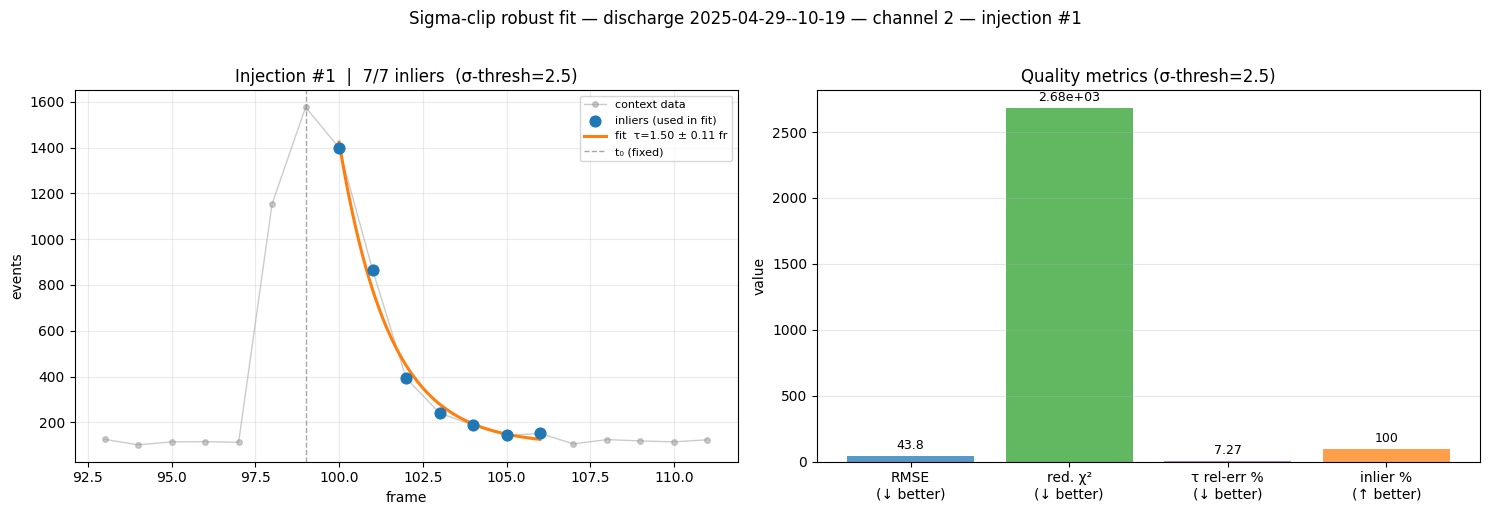

In [ ]:
"""Cell 5 — Visualization: show inliers/outliers and fit curve for injection #1 of a discharge 2025-04-29--10-19

Two panels:
  Left  — the injection region with inlier/outlier points colour-coded
           and the fitted curve drawn over ALL injection frames.
  Right — bar chart of the four quality metrics for sigma_thresh=2.5.
"""

if not result["success"]:
    print("No successful fit to plot.")
else:
    fn  = trace.frame_numbers
    v   = trace.values
    t_all      = result["t_all"]
    y_all      = result["y_all"]
    inlier_mask = result["inlier_mask"]

    A, tau, t_0, C_bg = result["A"], result["tau"], result["t_0"], result["C_bg"]

    # dense curve for plotting
    t_curve = np.linspace(float(t_all[0]), float(t_all[-1]), 300)
    y_curve = _exp_model(t_curve, A, tau, t_0, C_bg)

    # slightly wider context window
    ctx_lo = max(0, injection.start_frame - 5)
    ctx_hi = min(int(fn[-1]), injection.finish_frame + 5)
    ctx_mask = (fn >= ctx_lo) & (fn <= ctx_hi)

    fig, (ax_fit, ax_metrics) = plt.subplots(1, 2, figsize=(15, 5))

    # ---- left panel: fit + inlier/outlier annotation ----
    # background context (grey, faint)
    ax_fit.plot(fn[ctx_mask], v[ctx_mask], "o-", ms=4, lw=1,
                color="0.6", alpha=0.5, zorder=1, label="context data")

    # inliers (blue circles)
    ax_fit.scatter(t_all[inlier_mask], y_all[inlier_mask],
                   s=60, color="tab:blue", zorder=4, label="inliers (used in fit)")

    # outliers (red X)
    if (~inlier_mask).any():
        ax_fit.scatter(t_all[~inlier_mask], y_all[~inlier_mask],
                       s=80, marker="x", color="tab:red", linewidths=2,
                       zorder=5, label="outliers (sigma-clipped)")

    # fitted curve
    ax_fit.plot(t_curve, y_curve, color="tab:orange", lw=2.2, zorder=3,
                label=f"fit  τ={tau:.2f} ± {result['tau_err']:.2f} fr")

    ax_fit.axvline(injection.start_frame + 1, color="gray", ls="--", lw=1,
                   alpha=0.7, label="t₀ (fixed)")
    ax_fit.set_xlabel("frame")
    ax_fit.set_ylabel("events")
    ax_fit.set_title(f"Injection #{injection.injection_no}  |  "
                     f"{result['n_inliers']}/{result['n_total']} inliers  "
                     f"(σ-thresh=2.5)")
    ax_fit.legend(fontsize=8)
    ax_fit.grid(alpha=0.25)

    # ---- right panel: metric bar chart ----
    metric_names  = ["RMSE\n(↓ better)", "red. χ²\n(↓ better)",
                     "τ rel-err %\n(↓ better)", "inlier %\n(↑ better)"]
    metric_values = [
        result["rmse_inliers"],
        result["reduced_chi2"],
        result["tau_err_rel"] * 100,
        result["inlier_fraction"] * 100,
    ]
    colors = ["tab:blue", "tab:green", "tab:purple", "tab:orange"]
    bars = ax_metrics.bar(metric_names, metric_values, color=colors, alpha=0.75)
    for bar, val in zip(bars, metric_values):
        ax_metrics.text(bar.get_x() + bar.get_width() / 2,
                        bar.get_height() + max(metric_values) * 0.01,
                        f"{val:.3g}", ha="center", va="bottom", fontsize=9)
    ax_metrics.set_title("Quality metrics (σ-thresh=2.5)")
    ax_metrics.set_ylabel("value")
    ax_metrics.grid(axis="y", alpha=0.3)

    fig.suptitle(
        f"Sigma-clip robust fit — discharge 2025-04-29--10-19 — "
        f"channel {CHANNEL_ID} — injection #{injection.injection_no}",
        y=1.02, fontsize=12,
    )
    fig.tight_layout()
    plt.show()


Injection #1  span = frames 98..106
  Original t_0 (start_frame+1)    = frame 99
  Auto-detected t_0 (first fall)  = frame 100
  → t_0 shifted: measured peak is not at start_frame+1


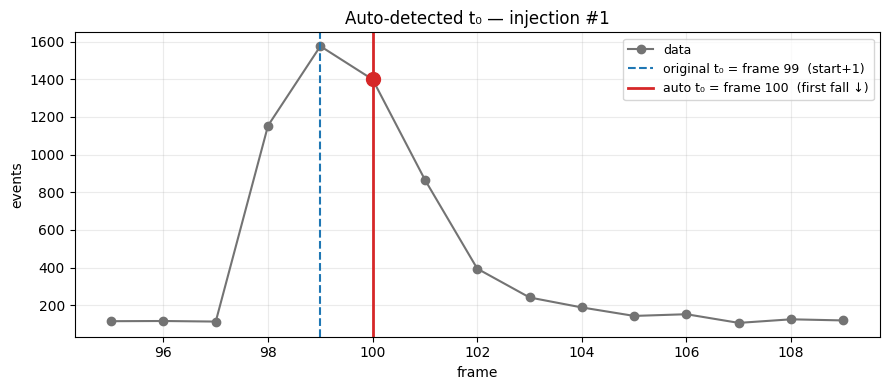

In [ ]:
"""Cell 7 — Demo: show where auto-detected t_0 lands vs original convention. for injection #1 of a discharge 2025-04-29--10-19"""

auto_t0_frame = find_first_falling_frame(trace, injection)
original_t0   = int(injection.start_frame + 1)

print(f"Injection #{injection.injection_no}  "
      f"span = frames {injection.start_frame}..{injection.finish_frame}")
print(f"  Original t_0 (start_frame+1)    = frame {original_t0}")
print(f"  Auto-detected t_0 (first fall)  = frame {auto_t0_frame}")
if auto_t0_frame != original_t0:
    print("  → t_0 shifted: measured peak is not at start_frame+1")
else:
    print("  → t_0 unchanged: decay starts right at the second burst point")

# --- plot: mark both t_0 candidates on the injection data ---
fn_   = trace.frame_numbers
v_    = trace.values
ctx_lo_ = max(0, injection.start_frame - 3)
ctx_hi_ = min(int(fn_[-1]), injection.finish_frame + 3)
ctx_  = (fn_ >= ctx_lo_) & (fn_ <= ctx_hi_)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(fn_[ctx_], v_[ctx_], "o-", ms=6, color="0.45", lw=1.5, label="data")
ax.axvline(original_t0,   color="tab:blue", ls="--", lw=1.5,
           label=f"original t₀ = frame {original_t0}  (start+1)")
ax.axvline(auto_t0_frame, color="tab:red",  ls="-",  lw=2,
           label=f"auto t₀ = frame {auto_t0_frame}  (first fall ↓)")
ax.scatter([auto_t0_frame], [v_[fn_ == auto_t0_frame][0]],
           s=100, zorder=5, color="tab:red")
ax.set_xlabel("frame")
ax.set_ylabel("events")
ax.set_title(f"Auto-detected t₀ — injection #{injection.injection_no}")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()


NameError: name 'fit_sigma_clip' is not defined

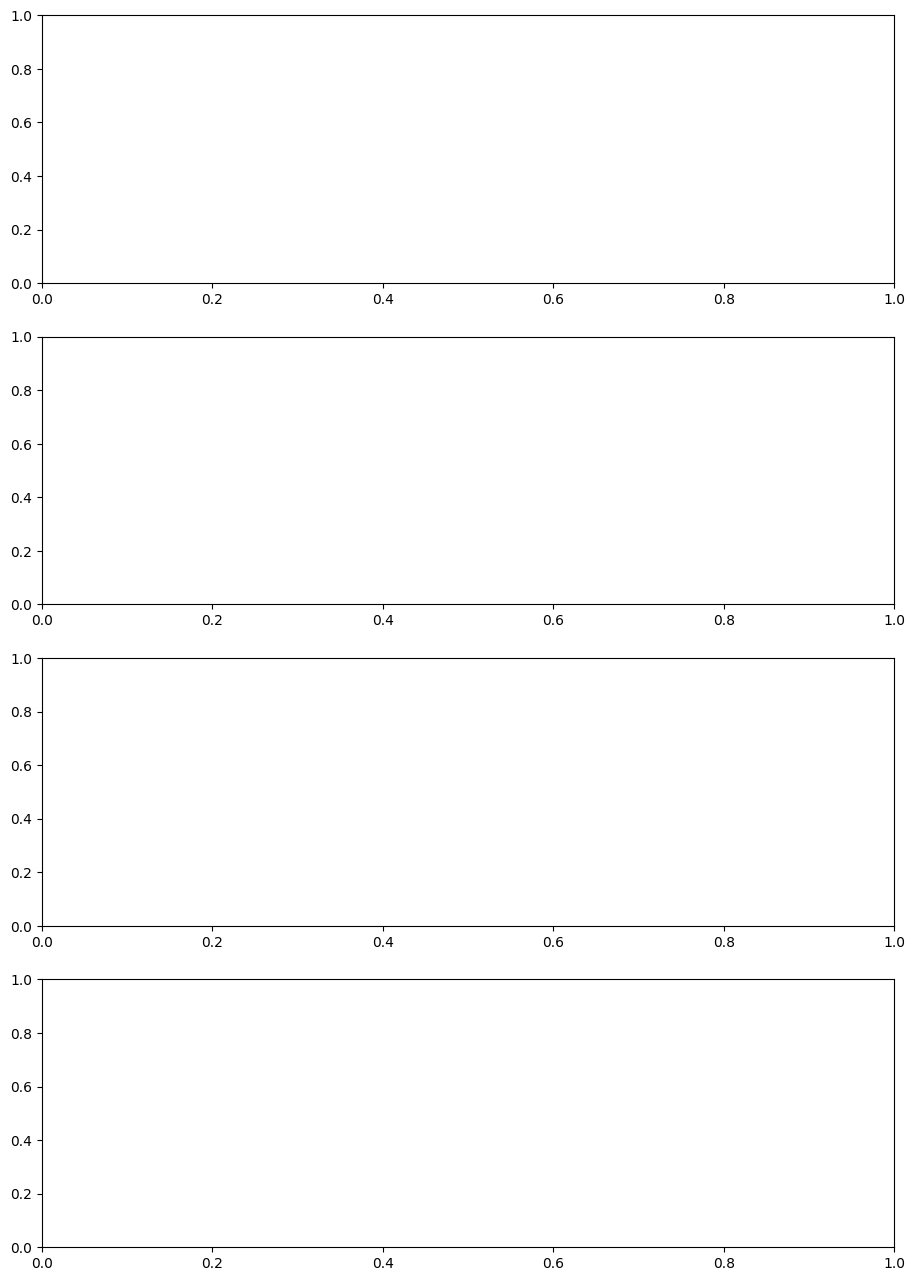

In [3]:
"""Cell 8 — Fit all injections and plot each one. discharge 2025-04-29--10-19"""

fn_ = trace.frame_numbers
v_  = trace.values

fig, axes = plt.subplots(
    len(injections), 1,
    figsize=(11, 4 * len(injections)),
    squeeze=False,
)

for ax, inj in zip(axes[:, 0], injections):
    r = fit_sigma_clip(trace, inj, sigma_thresh=2.5)

    # context window around the injection
    ctx_lo = max(0, inj.start_frame - 4)
    ctx_hi = min(int(fn_[-1]), inj.finish_frame + 4)
    ctx    = (fn_ >= ctx_lo) & (fn_ <= ctx_hi)

    # faint full context
    ax.plot(fn_[ctx], v_[ctx], "o-", ms=4, lw=1, color="0.6", alpha=0.5,
            label="context data")

    if r["success"]:
        t_all       = r["t_all"]
        y_all       = r["y_all"]
        inlier_mask = r["inlier_mask"]
        A, tau, t_0, C_bg = r["A"], r["tau"], r["t_0"], r["C_bg"]

        # inliers and outliers
        ax.scatter(t_all[inlier_mask], y_all[inlier_mask],
                   s=55, color="tab:blue", zorder=4, label="inliers")
        if (~inlier_mask).any():
            ax.scatter(t_all[~inlier_mask], y_all[~inlier_mask],
                       s=70, marker="x", color="tab:red", linewidths=2,
                       zorder=5, label="sigma-clipped")

        # fitted curve over the decay span
        t_curve = np.linspace(float(t_all[0]), float(t_all[-1]), 300)
        y_curve = _exp_model(t_curve, A, tau, t_0, C_bg)
        ax.plot(t_curve, y_curve, color="tab:orange", lw=2.2, zorder=3,
                label=f"fit  τ={tau:.2f}±{r['tau_err']:.2f} fr  "
                      f"(τ_rel={r['tau_err_rel']*100:.1f}%,  "
                      f"inliers={r['n_inliers']}/{r['n_total']})")

        # mark auto-detected t_0
        ax.axvline(t_0, color="tab:red", ls="-", lw=1.3, alpha=0.7,
                   label=f"auto t₀={int(t_0)}")
    else:
        # show failure message in title
        ax.text(0.5, 0.5, f"fit failed: {r['message']}",
                transform=ax.transAxes, ha="center", va="center",
                color="red", fontsize=10)

    ax.set_title(f"Injection #{inj.injection_no}  "
                 f"(frames {inj.start_frame}–{inj.finish_frame})")
    ax.set_xlabel("frame")
    ax.set_ylabel("events")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

fig.suptitle(
    f"All injections — discharge 2025-04-29--10-19 — channel {CHANNEL_ID}",
    fontsize=13, y=1.01,
)
fig.tight_layout()
plt.show()


Loaded: test
Channel 2: 5 injection(s) detected
  #1  frames 63..67  (span=4)
  #2  frames 99..111  (span=12)
  #3  frames 146..157  (span=11)
  #4  frames 194..204  (span=10)
  #5  frames 280..292  (span=12)


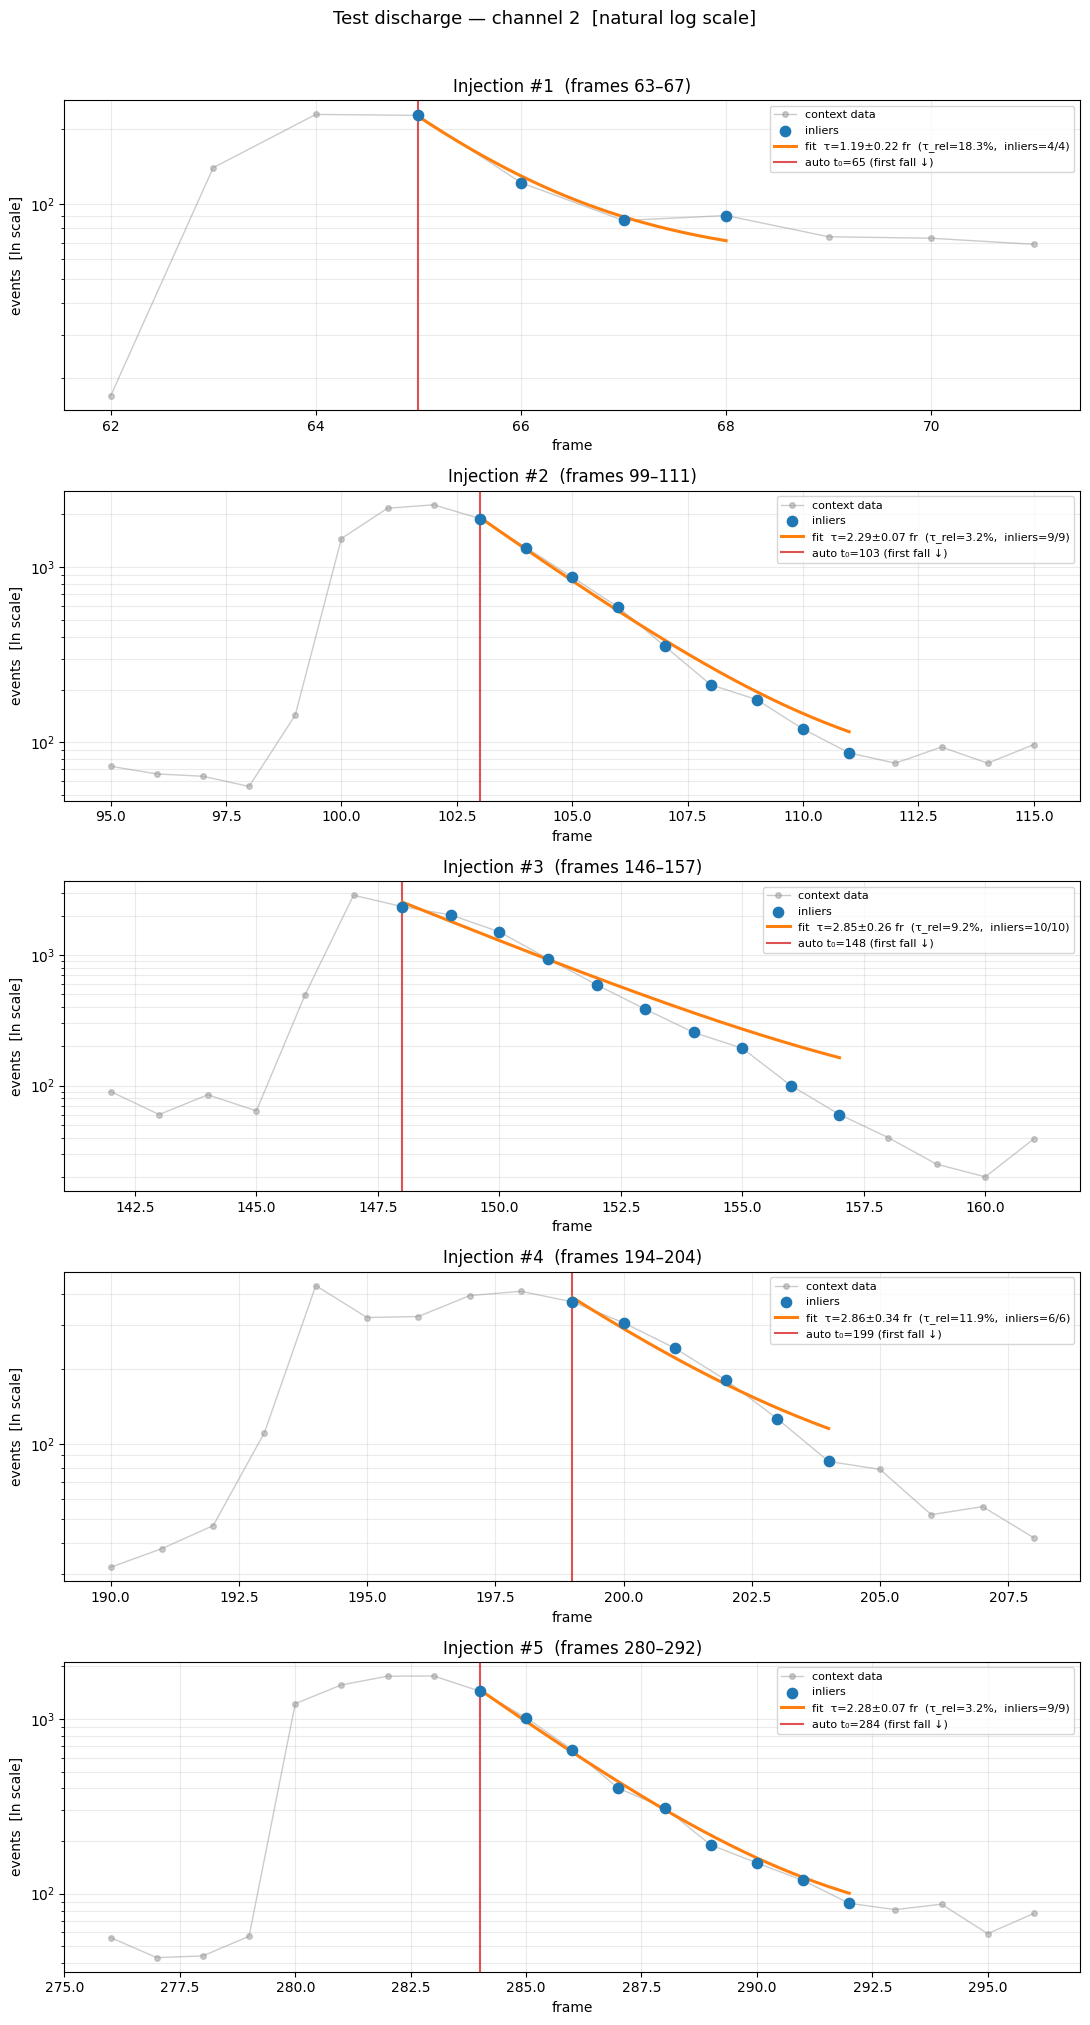

In [5]:
"""Cell 9 — Load test discharge, fit all injections, plot each one (log scale). discharge test"""

TEST_DIR = ROOT / "data" / "discharges" / "test"

# load test discharge and build trace
test_discharge  = io.load_test_folder(TEST_DIR, discharge_id="test")
test_channel    = test_discharge.channels[CHANNEL_ID]
test_trace      = integrate_energy_window(test_channel, LINE_E, HALF_W)
test_injections = detect_injections(test_trace, LINE_E)

print(f"Loaded: {test_discharge.discharge_id}")
print(f"Channel {CHANNEL_ID}: {len(test_injections)} injection(s) detected")
for inj in test_injections:
    print(f"  #{inj.injection_no}  frames {inj.start_frame}..{inj.finish_frame}  "
          f"(span={inj.finish_frame - inj.start_frame})")

if not test_injections:
    print("No injections detected — nothing to plot.")
else:
    t_fn = test_trace.frame_numbers
    t_v  = test_trace.values

    fig, axes = plt.subplots(
        len(test_injections), 1,
        figsize=(11, 4 * len(test_injections)),
        squeeze=False,
    )

    for ax, inj in zip(axes[:, 0], test_injections):
        r = fit_sigma_clip(test_trace, inj, sigma_thresh=2.5)

        # auto-detected t_0 for this injection
        auto_t0 = find_first_falling_frame(test_trace, inj)

        # context window around the injection
        ctx_lo = max(0, inj.start_frame - 4)
        ctx_hi = min(int(t_fn[-1]), inj.finish_frame + 4)
        ctx    = (t_fn >= ctx_lo) & (t_fn <= ctx_hi)

        # clip context values to be > 0 so log scale works
        ctx_v_safe = np.where(t_v[ctx] > 0, t_v[ctx], np.nan)

        # faint context data
        ax.plot(t_fn[ctx], ctx_v_safe, "o-", ms=4, lw=1, color="0.6",
                alpha=0.5, label="context data")

        if r["success"]:
            t_all_r       = r["t_all"]
            y_all_r       = r["y_all"]
            inlier_mask_r = r["inlier_mask"]
            A_r, tau_r, t0_r, Cbg_r = r["A"], r["tau"], r["t_0"], r["C_bg"]

            # inliers (blue) and sigma-clipped outliers (red X)
            # clip to > 0 before log plotting
            y_inliers = np.where(y_all_r[inlier_mask_r] > 0,
                                 y_all_r[inlier_mask_r], np.nan)
            ax.scatter(t_all_r[inlier_mask_r], y_inliers,
                       s=55, color="tab:blue", zorder=4, label="inliers")

            if (~inlier_mask_r).any():
                y_out = np.where(y_all_r[~inlier_mask_r] > 0,
                                 y_all_r[~inlier_mask_r], np.nan)
                ax.scatter(t_all_r[~inlier_mask_r], y_out,
                           s=70, marker="x", color="tab:red", linewidths=2,
                           zorder=5, label="sigma-clipped")

            # fitted exponential curve — on log scale a pure exp is a straight line
            t_curve_r = np.linspace(float(t_all_r[0]), float(t_all_r[-1]), 300)
            y_curve_r = _exp_model(t_curve_r, A_r, tau_r, t0_r, Cbg_r)
            ax.plot(t_curve_r, np.where(y_curve_r > 0, y_curve_r, np.nan),
                    color="tab:orange", lw=2.2, zorder=3,
                    label=f"fit  τ={tau_r:.2f}±{r['tau_err']:.2f} fr  "
                          f"(τ_rel={r['tau_err_rel']*100:.1f}%,  "
                          f"inliers={r['n_inliers']}/{r['n_total']})")

        # mark auto-detected t_0 from find_first_falling_frame
        ax.axvline(auto_t0, color="tab:red", ls="-", lw=1.5, alpha=0.8,
                   label=f"auto t₀={auto_t0} (first fall ↓)")

        # natural log scale on y-axis
        ax.set_yscale("log")

        ax.set_title(f"Injection #{inj.injection_no}  "
                     f"(frames {inj.start_frame}–{inj.finish_frame})")
        ax.set_xlabel("frame")
        ax.set_ylabel("events  [ln scale]")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.25, which="both")

    fig.suptitle(
        f"Test discharge — channel {CHANNEL_ID}  [natural log scale]",
        fontsize=13, y=1.01,
    )
    fig.tight_layout()
    plt.show()


In [19]:
"""Cell 10 — fit_sigma_clip_monotone(): pre-rejects rising points before sigma-clipping.

Why the old function fails on injection #3:
  High-leverage masking — anomalous early points (close to t_0) pull the fit
  toward them. Their residuals appear small, so MAD is inflated, and the
  sigma-clip threshold never fires. Good trailing points end up with larger
  residuals and can even get clipped instead.

Fix — physically-motivated pre-rejection:
  After t_0 the decay MUST be monotonically non-increasing (physics).
  Any point i where y[i] > y[i-1] is a plasma instability artifact.
  We reject those unconditionally, BEFORE any fitting or sigma-clipping.
  This breaks the high-leverage masking because the fit never sees those points.
"""

def fit_sigma_clip_monotone(
    trace,
    injection,
    sigma_thresh: float = 2.5,
    max_iter: int = 10,
    min_inliers: int = 4,
) -> dict:
    """Robust fit with physical monotone pre-rejection + iterative sigma-clipping.

    Identical to fit_sigma_clip() except for one extra step inserted before
    the sigma-clipping loop:

      Step 0: pre-reject any point i (i > 0 in the decay span) where
              y[i] > y[i-1].  These violate the known physics of exponential
              decay and are unconditionally excluded before any fit is run.

    This prevents high-leverage masking where early anomalous points corrupt
    the seed fit and hide themselves from the residual-based rejection.

    Returns the same dict structure as fit_sigma_clip(), with the additional key:
      n_monotone_rejected : number of points removed in the pre-rejection step
    """
    fn = trace.frame_numbers
    v  = trace.values

    t_0  = float(find_first_falling_frame(trace, injection))
    C_bg = float(np.median(v))

    try:
        start_idx = int(np.where(fn == int(t_0))[0][0])
    except IndexError:
        return _fail_m(f"t_0={int(t_0)} not in trace", t_0, C_bg)

    try:
        end_idx = int(np.where(fn == int(injection.finish_frame))[0][0]) + 1
    except IndexError:
        end_idx = len(fn)
    end_idx = max(end_idx, start_idx + min_inliers)

    t_all   = fn[start_idx:end_idx].astype(float)
    y_all   = v[start_idx:end_idx].astype(float)
    n_total = len(t_all)

    if n_total < min_inliers:
        return _fail_m(f"decay span too short ({n_total} pts)", t_0, C_bg)

    # --- Step 0: physical pre-rejection of rising steps ---
    # For each point after the first, reject it if it is above the previous point.
    # Because the true decay is monotone-decreasing, any rise is an artifact.
    pre_mask = np.ones(n_total, dtype=bool)
    for i in range(1, n_total):
        if y_all[i] > y_all[i - 1]:
            # this point rises relative to the previous — physically impossible
            pre_mask[i] = False

    n_monotone_rejected = int((~pre_mask).sum())

    if pre_mask.sum() < min_inliers:
        return _fail_m(
            f"too few points after monotone pre-rejection ({pre_mask.sum()})",
            t_0, C_bg,
        )

    # --- Step 1: robust seed on pre-filtered points ---
    def _res(params, t, y):
        A, tau = params
        return _exp_model(t, A, tau, t_0, C_bg) - y

    p0 = _initial_guess(y_all[pre_mask], t_0, C_bg)
    try:
        seed = least_squares(
            _res, p0,
            args=(t_all[pre_mask], y_all[pre_mask]),
            loss='soft_l1',
            f_scale=float(np.std(y_all[pre_mask])) or 1.0,
            bounds=([0, 0.01], [np.inf, np.inf]),
            max_nfev=5000,
        )
        A_seed, tau_seed = seed.x
    except Exception:
        A_seed, tau_seed = p0

    # --- Step 2: iterative sigma-clipping starting from the pre-filtered set ---
    inlier_mask = pre_mask.copy()

    for iteration in range(max_iter):
        t_in = t_all[inlier_mask]
        y_in = y_all[inlier_mask]

        if len(t_in) < min_inliers:
            break

        try:
            popt, pcov = curve_fit(
                lambda t, A, tau: _exp_model(t, A, tau, t_0, C_bg),
                t_in, y_in,
                p0=[A_seed, tau_seed],
                maxfev=5000,
            )
        except Exception:
            break

        A_fit, tau_fit = popt

        # residuals over ALL points (to catch any remaining outliers)
        resid_all = y_all - _exp_model(t_all, A_fit, tau_fit, t_0, C_bg)

        mad = _MAD_SCALE * np.median(np.abs(resid_all[inlier_mask]))
        if mad < 1e-12:
            break

        # candidate new mask: sigma-clip AND preserve the monotone pre-rejection
        new_mask = (np.abs(resid_all) <= sigma_thresh * mad) & pre_mask

        if new_mask.sum() < min_inliers:
            new_mask = inlier_mask  # revert

        if np.array_equal(new_mask, inlier_mask):
            inlier_mask = new_mask
            break

        inlier_mask = new_mask
        A_seed, tau_seed = A_fit, tau_fit

    # --- Step 3: final OLS fit ---
    t_in = t_all[inlier_mask]
    y_in = y_all[inlier_mask]
    n_in = int(inlier_mask.sum())

    if n_in < min_inliers:
        return _fail_m(f"too few inliers ({n_in}) after clipping", t_0, C_bg)

    try:
        popt, pcov = curve_fit(
            lambda t, A, tau: _exp_model(t, A, tau, t_0, C_bg),
            t_in, y_in,
            p0=[A_seed, tau_seed],
            maxfev=5000,
        )
    except Exception as exc:
        return _fail_m(f"final fit failed: {exc}", t_0, C_bg)

    A_fit, tau_fit = float(popt[0]), float(popt[1])

    diag = np.diag(pcov).astype(float)
    diag[diag < 0] = np.nan
    A_err, tau_err = float(np.sqrt(diag[0])), float(np.sqrt(diag[1]))

    resid_in = y_in - _exp_model(t_in, A_fit, tau_fit, t_0, C_bg)
    rss      = float(np.sum(resid_in ** 2))
    dof      = n_in - 2
    rmse     = float(np.sqrt(rss / n_in))
    red_chi2 = float(rss / dof) if dof > 0 else np.nan

    return {
        "success":              True,
        "A":                    A_fit,
        "tau":                  tau_fit,
        "t_0":                  t_0,
        "C_bg":                 C_bg,
        "A_err":                A_err,
        "tau_err":              tau_err,
        "inlier_mask":          inlier_mask,
        "pre_mask":             pre_mask,        # mask after monotone rejection only
        "t_all":                t_all,
        "y_all":                y_all,
        "n_total":              n_total,
        "n_inliers":            n_in,
        "n_monotone_rejected":  n_monotone_rejected,
        "inlier_fraction":      n_in / n_total,
        "rss_inliers":          rss,
        "rmse_inliers":         rmse,
        "reduced_chi2":         red_chi2,
        "tau_err_rel":          tau_err / abs(tau_fit) if tau_fit != 0 else np.nan,
        "message":              (
            f"ok (t_0={int(t_0)}, monotone_rej={n_monotone_rejected}, "
            f"iter={iteration+1}, inliers={n_in}/{n_total})"
        ),
        "iterations":           iteration + 1,
    }


def _fail_m(msg, t_0, C_bg):
    nan = float("nan")
    return {
        "success": False, "message": msg,
        "A": nan, "tau": nan, "t_0": t_0, "C_bg": C_bg,
        "A_err": nan, "tau_err": nan,
        "inlier_mask": None, "pre_mask": None,
        "t_all": None, "y_all": None,
        "n_total": 0, "n_inliers": 0, "n_monotone_rejected": 0,
        "inlier_fraction": nan, "rss_inliers": nan, "rmse_inliers": nan,
        "reduced_chi2": nan, "tau_err_rel": nan, "iterations": 0,
    }


print("fit_sigma_clip_monotone() defined.")


fit_sigma_clip_monotone() defined.


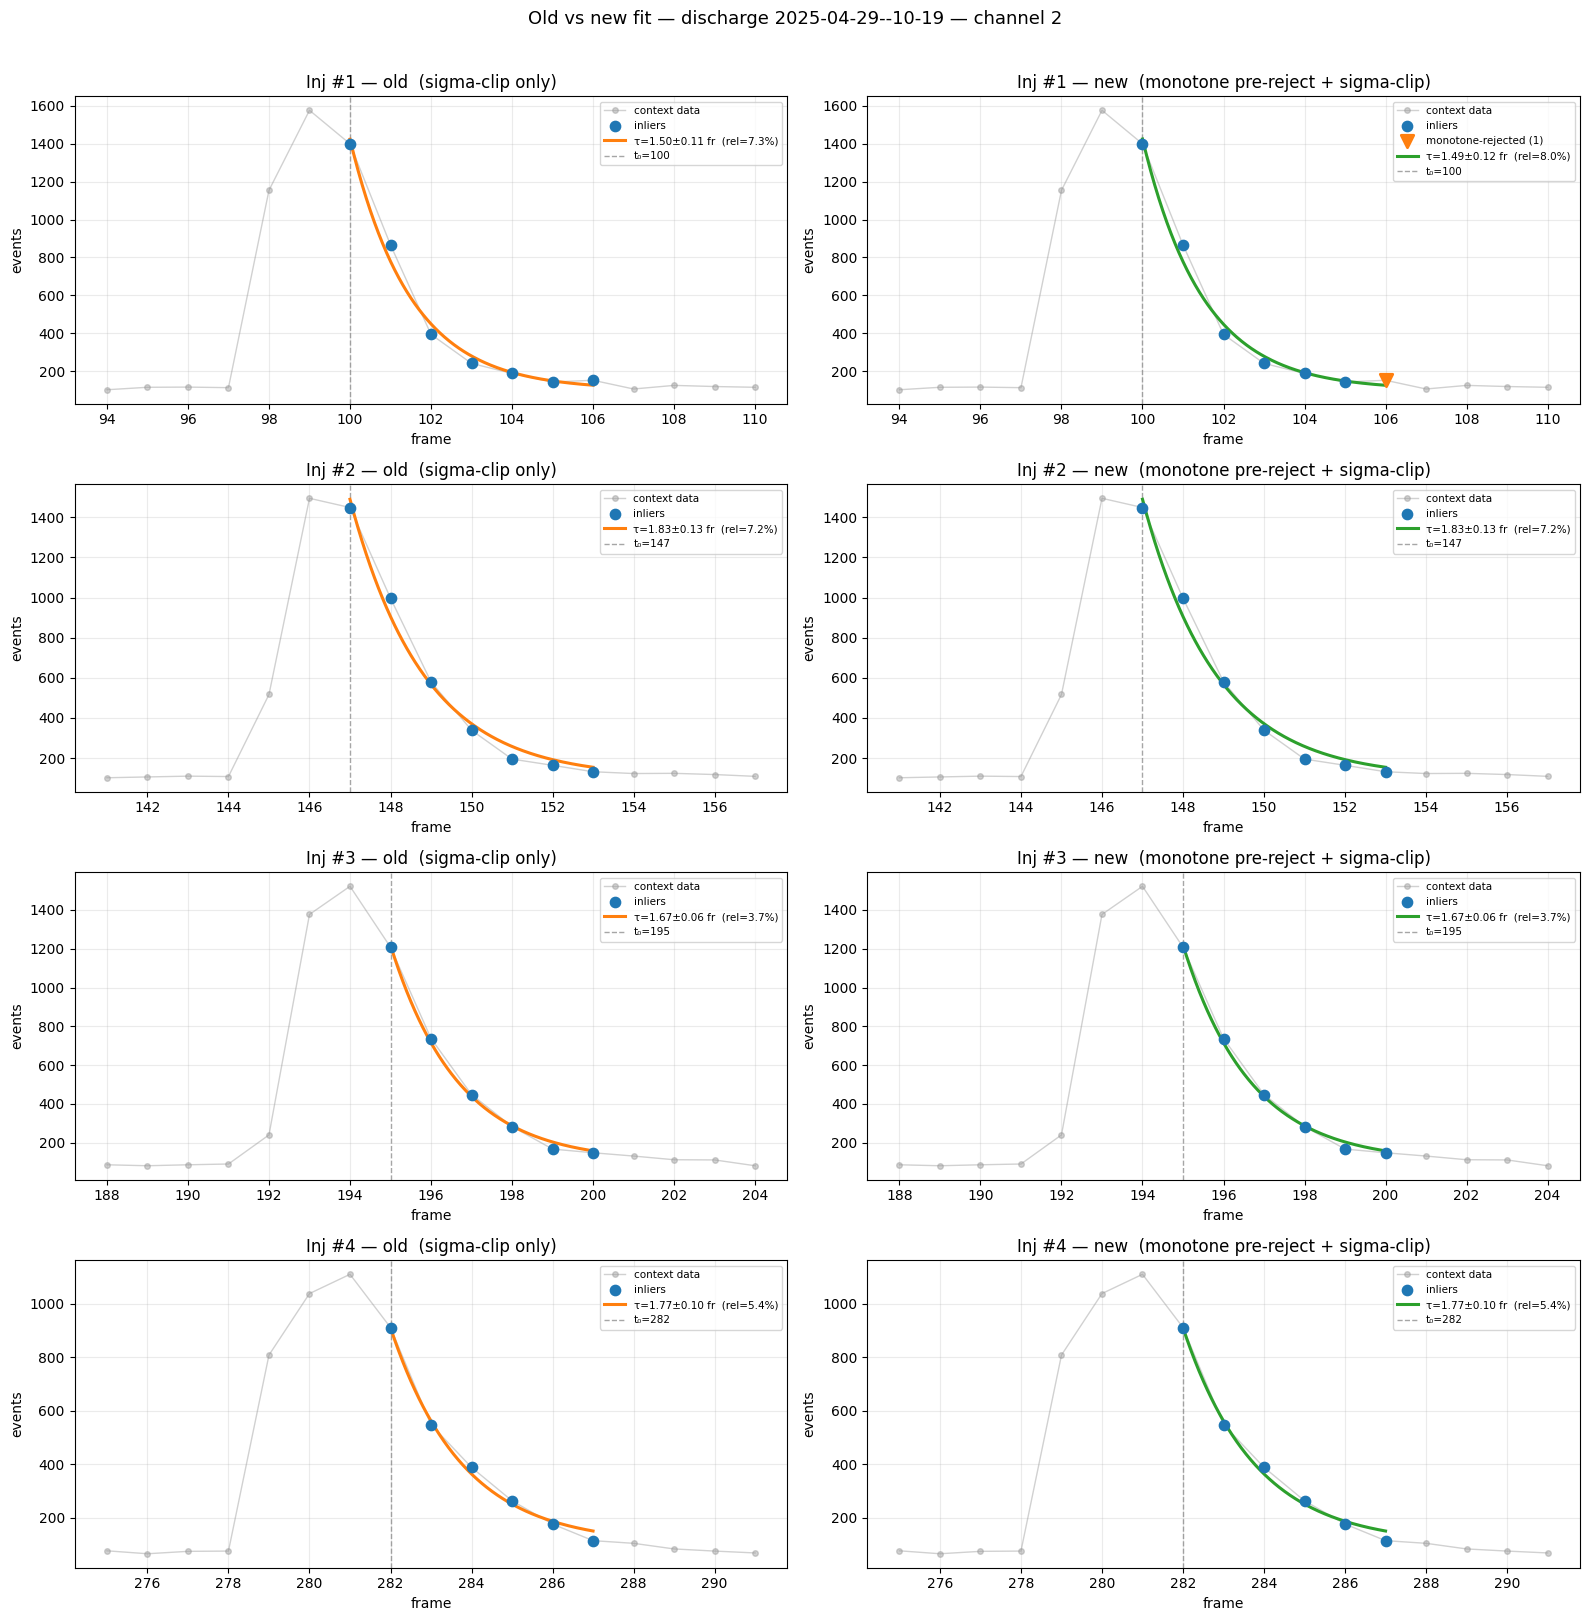

In [20]:
"""Cell 11 — Compare fit_sigma_clip vs fit_sigma_clip_monotone on all injections.

Left panel : old function (no monotone pre-rejection)
Right panel: new function (monotone pre-rejection first)

Monotone-rejected points are shown as orange triangles in the right panel.
"""

fn_ = trace.frame_numbers
v_  = trace.values

fig, axes = plt.subplots(
    len(injections), 2,
    figsize=(16, 4 * len(injections)),
    squeeze=False,
)

for row, inj in enumerate(injections):
    r_old = fit_sigma_clip(trace, inj, sigma_thresh=2.5)
    r_new = fit_sigma_clip_monotone(trace, inj, sigma_thresh=2.5)

    ctx_lo = max(0, inj.start_frame - 4)
    ctx_hi = min(int(fn_[-1]), inj.finish_frame + 4)
    ctx    = (fn_ >= ctx_lo) & (fn_ <= ctx_hi)

    for col, (r, label) in enumerate([
        (r_old, "old  (sigma-clip only)"),
        (r_new, "new  (monotone pre-reject + sigma-clip)"),
    ]):
        ax = axes[row, col]
        ax.plot(fn_[ctx], v_[ctx], "o-", ms=4, lw=1, color="0.6",
                alpha=0.45, label="context data")

        if r["success"]:
            t_a = r["t_all"]
            y_a = r["y_all"]
            im  = r["inlier_mask"]

            ax.scatter(t_a[im], y_a[im], s=55, color="tab:blue",
                       zorder=4, label="inliers")

            # sigma-clipped (after pre-rejection) — red X
            sigma_clipped = ~im
            if col == 1:
                # separate monotone-rejected (orange ▼) from sigma-clipped (red X)
                pm = r["pre_mask"]
                mono_rej  = ~pm                   # rising-step rejects
                sigma_clipped = pm & ~im           # passed monotone, but sigma-clipped
                if mono_rej.any():
                    ax.scatter(t_a[mono_rej], y_a[mono_rej],
                               s=80, marker="v", color="tab:orange", linewidths=2,
                               zorder=5, label=f"monotone-rejected ({mono_rej.sum()})")

            if sigma_clipped.any():
                ax.scatter(t_a[sigma_clipped], y_a[sigma_clipped],
                           s=80, marker="x", color="tab:red", linewidths=2,
                           zorder=5, label=f"sigma-clipped ({sigma_clipped.sum()})")

            t_c = np.linspace(float(t_a[0]), float(t_a[-1]), 300)
            y_c = _exp_model(t_c, r["A"], r["tau"], r["t_0"], r["C_bg"])
            ax.plot(t_c, y_c, color="tab:orange" if col == 0 else "tab:green",
                    lw=2.2, zorder=3,
                    label=f"τ={r['tau']:.2f}±{r['tau_err']:.2f} fr  "
                          f"(rel={r['tau_err_rel']*100:.1f}%)")
            ax.axvline(r["t_0"], color="gray", ls="--", lw=1, alpha=0.7,
                       label=f"t₀={int(r['t_0'])}")
        else:
            ax.text(0.5, 0.5, f"failed: {r['message']}",
                    transform=ax.transAxes, ha="center", color="red")

        ax.set_title(f"Inj #{inj.injection_no} — {label}")
        ax.set_xlabel("frame")
        ax.set_ylabel("events")
        ax.legend(fontsize=7.5)
        ax.grid(alpha=0.25)

fig.suptitle(
    f"Old vs new fit — discharge 2025-04-29--10-19 — channel {CHANNEL_ID}",
    fontsize=13, y=1.01,
)
fig.tight_layout()
plt.show()


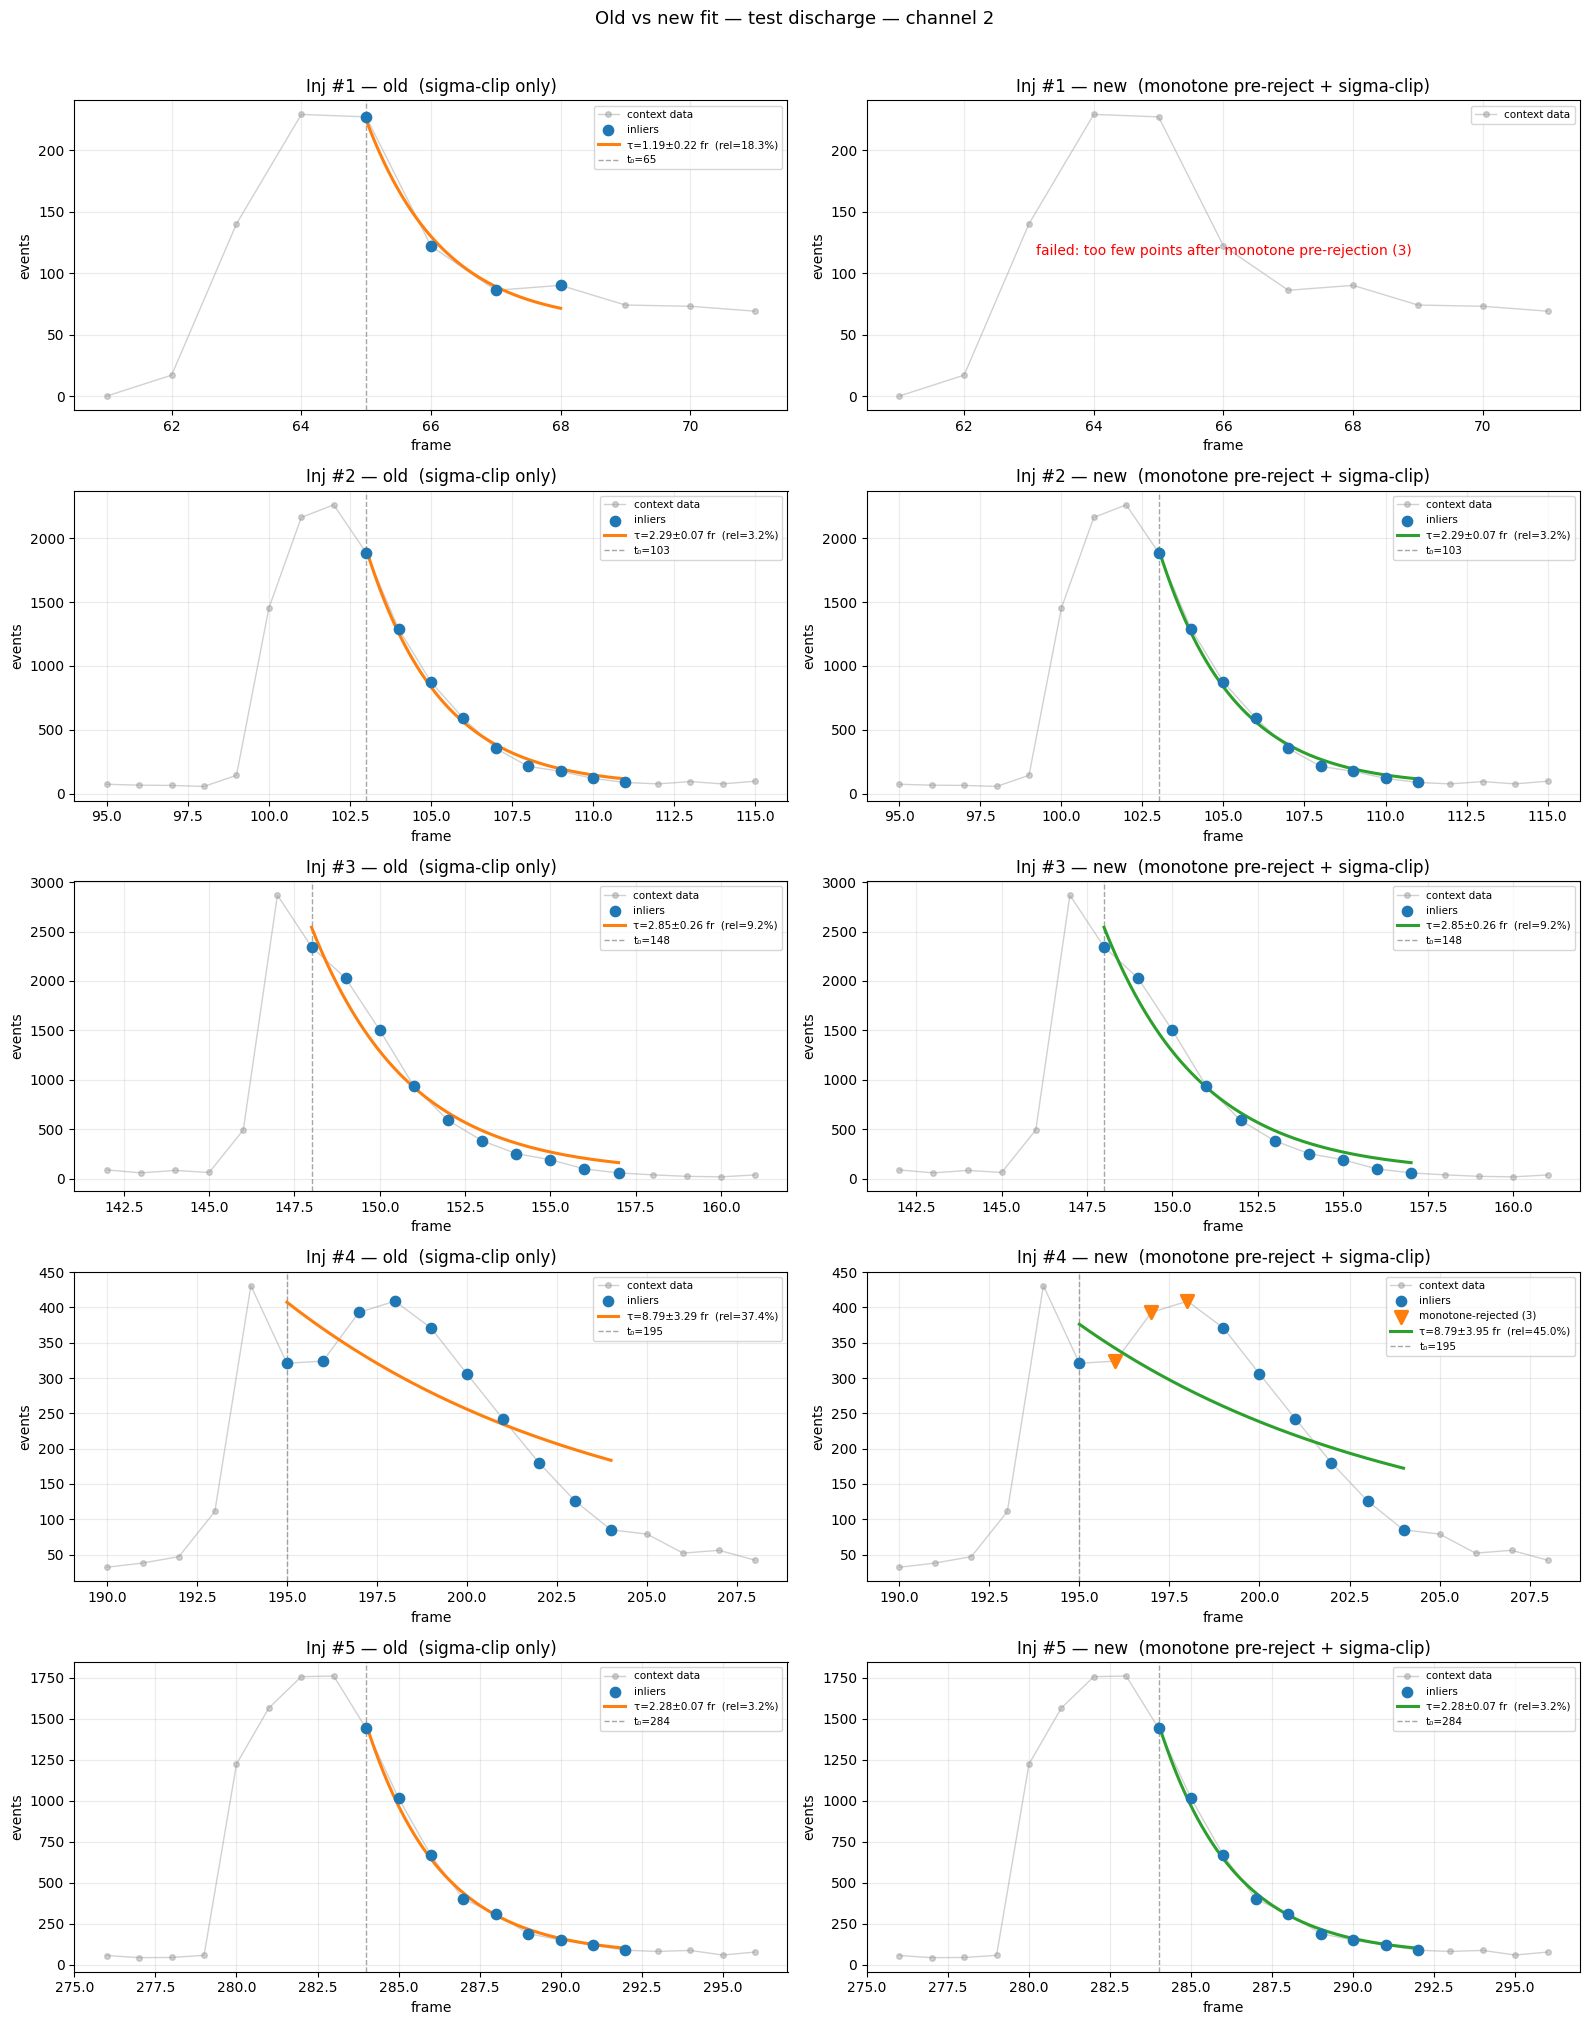

In [ ]:
"""Old vs new fit comparison on the TEST discharge."""

test_fn_ = test_trace.frame_numbers
test_v_  = test_trace.values

test_fig, test_axes = plt.subplots(
    len(test_injections), 2,
    figsize=(16, 4 * len(test_injections)),
    squeeze=False,
)

for row, inj in enumerate(test_injections):
    # both functions called on test_trace / test injections
    r_old = fit_sigma_clip(test_trace, inj, sigma_thresh=2.5)
    r_new = fit_sigma_clip_monotone(test_trace, inj, sigma_thresh=2.5)

    ctx_lo = max(0, inj.start_frame)
    
    ctx_hi = min(int(test_fn_[-1]), inj.finish_frame + 4)
    ctx    = (test_fn_ >= ctx_lo) & (test_fn_ <= ctx_hi)

    for col, (r, label) in enumerate([
        (r_old, "old  (sigma-clip only)"),
        (r_new, "new  (monotone pre-reject + sigma-clip)"),
    ]):
        ax = test_axes[row, col]
        ax.plot(test_fn_[ctx], test_v_[ctx], "o-", ms=4, lw=1, color="0.6",
                alpha=0.45, label="context data")

        if r["success"]:
            t_a = r["t_all"]
            y_a = r["y_all"]
            im  = r["inlier_mask"]

            ax.scatter(t_a[im], y_a[im], s=55, color="tab:blue",
                       zorder=4, label="inliers")

            sigma_clipped = ~im
            if col == 1:
                pm            = r["pre_mask"]
                mono_rej      = ~pm
                sigma_clipped = pm & ~im
                if mono_rej.any():
                    ax.scatter(t_a[mono_rej], y_a[mono_rej],
                               s=80, marker="v", color="tab:orange", linewidths=2,
                               zorder=5, label=f"monotone-rejected ({mono_rej.sum()})")

            if sigma_clipped.any():
                ax.scatter(t_a[sigma_clipped], y_a[sigma_clipped],
                           s=80, marker="x", color="tab:red", linewidths=2,
                           zorder=5, label=f"sigma-clipped ({sigma_clipped.sum()})")

            t_c = np.linspace(float(t_a[0]), float(t_a[-1]), 300)
            y_c = _exp_model(t_c, r["A"], r["tau"], r["t_0"], r["C_bg"])
            ax.plot(t_c, y_c, color="tab:orange" if col == 0 else "tab:green",
                    lw=2.2, zorder=3,
                    label=f"τ={r['tau']:.2f}±{r['tau_err']:.2f} fr  "
                          f"(rel={r['tau_err_rel']*100:.1f}%)")
            ax.axvline(r["t_0"], color="gray", ls="--", lw=1, alpha=0.7,
                       label=f"t₀={int(r['t_0'])}")
        else:
            ax.text(0.5, 0.5, f"failed: {r['message']}",
                    transform=ax.transAxes, ha="center", color="red")

        ax.set_title(f"Inj #{inj.injection_no} — {label}")
        ax.set_xlabel("frame")
        ax.set_ylabel("events")
        ax.legend(fontsize=7.5)
        ax.grid(alpha=0.25)

test_fig.suptitle(
    f"Old vs new fit — test discharge — channel {CHANNEL_ID}",
    fontsize=13, y=1.01,
)
test_fig.tight_layout()
plt.show()
